# **Extended Data Figure 9**
Reproduces Extended Data Figure 9 from simulation data. Data used:

- `DNb08_Stim/hyak/run_id=32924488` (**a**)
- `DNb08_Stim_CoreCPG_1/default/run_id=walle_20260223_00` (**c–d**) 
- `DNb08_Stim_CoreCPG_2/default/run_id=walle_20260221_0` (**e–f**)

In [ ]:
dataPath = "/data/users/smpuglie/published-simulations/"

In [ ]:
import matplotlib.pyplot as plt
from src.utils.plot_utils import *
from src.utils.sim_utils import *
import yaml
import numpy as np
import jax.numpy as jnp
import sparse
from hydra import initialize, compose
from hydra.core.hydra_config import HydraConfig
from omegaconf import DictConfig, OmegaConf
from pathlib import Path, PosixPath
import h5py

# # PLOT defaults
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["axes.spines.right"] = "False"
plt.rcParams["axes.spines.top"] = "False"
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["figure.figsize"] = (2,2)
plt.rcParams['axes.linewidth'] = 0.25
plt.rcParams["xtick.major.size"] = 1.7
plt.rcParams["xtick.minor.size"] = 1.0
plt.rcParams["ytick.major.size"] = 1.7
plt.rcParams["xtick.major.width"] = 0.25
plt.rcParams["xtick.minor.width"] = 0.18
plt.rcParams["ytick.major.width"] = 0.25
plt.rcParams["figure.dpi"] = 200

plt.rcParams["axes.labelpad"] = 1.5
plt.rcParams["xtick.major.pad"] = 1.5
plt.rcParams["ytick.major.pad"] = 1.5

SMALL_SIZE = 6
LABEL_SIZE = 7
AXLABEL_SIZE = 8
TITLE_SIZE = 10

plt.rcParams["font.family"] = "Arial" # "Arial"
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=TITLE_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=AXLABEL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=LABEL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=TITLE_SIZE)  # fontsize of the figure title

moduleColors = get_module_colors()

dnColor = "#51bbad"
excColor = "#d84a2e"
inhColor = "#026b85"
mnColor = "#267655"
lightDnColor = "#a7dcd5ff"
lightExcColor = "#ff9985"
lightInhColor = "#00acd6"
connColormap = sns.blend_palette([inhColor,lightInhColor,"white",lightExcColor,excColor],as_cmap=True)

Using diffeqsolve-based neural simulation (original)


# DNb08 frequency vs $|I_\text{stim}|$

## load first time

In [2]:
simType = "DNb08_Stim"
simPath = simType+"/hyak/run_id=32924488"
folder = dataPath + simPath
overallParams = DictConfig(load_from_yaml(folder+"/multirun.yaml"))
wTable = pd.read_csv("../"+overallParams.experiment["dfPath"].split("vnc-connectome-sim")[1])
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])

nSims = overallParams.experiment.n_replicates
nActive = pd.DataFrame(index=np.arange(nSims))
nMnsActive = pd.DataFrame(index=np.arange(nSims))
simScore = pd.DataFrame(index=np.arange(nSims))
mnFreq = pd.DataFrame(index=np.arange(nSims))

subfolders = []
for f in os.listdir(folder):
    if os.path.isdir(f"{folder}/{f}"):
        subfolders.append(f)

for subfolder in subfolders:
    print(f"Loading {subfolder}")
    Rs = load_Rs_npz(folder+f"/{subfolder}/ckpt/{simType}_Rs.npz")
    dataset = 0
    params = DictConfig(load_from_yaml(folder+f"/{subfolder}/.hydra/config.yaml"))
    stimI = params.experiment.stimI[0]
    for i in range(nSims):
        # active neurons
        R = Rs[dataset,i].todense()
        
        nActive.loc[i,stimI] = sum(np.max(R,1)>0.01)
        activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
        nMnsActive.loc[i,stimI] = np.sum(activeMnsMask)
        activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
        score, freq = compute_oscillation_score(R[...,250:],activeMnsMaskPastTransient)
        simScore.loc[i,stimI] = score
        mnFreq.loc[i,stimI] = freq

figFolder = "../figures/"
figFolder += "-".join(str.split(simPath,"/"))

/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


Loading experiment.seed=81,experiment.stimI=[65]
Loading experiment.seed=81,experiment.stimI=[105]
Loading experiment.seed=81,experiment.stimI=[95]
Loading experiment.seed=81,experiment.stimI=[75]
Loading experiment.seed=81,experiment.stimI=[55]
Loading experiment.seed=81,experiment.stimI=[85]


In [3]:
nActive = nActive.transpose().sort_index().transpose()
nMnsActive = nMnsActive.transpose().sort_index().transpose()
simScore = simScore.transpose().sort_index().transpose()
mnFreq = mnFreq.transpose().sort_index().transpose()

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# nActive.to_csv(figFolder+"/nActive.csv")    
# nMnsActive.to_csv(figFolder+"/nMnsActive.csv")
# simScore.to_csv(figFolder+"/scores.csv")
# mnFreq.to_csv(figFolder+"/frequencies.csv")

## reload and plot

In [ ]:
simType = "DNb08_Stim"
simPath = simType+"/hyak/run_id=32924488"
folder = dataPath + simPath
overallParams = DictConfig(load_from_yaml(folder+"/multirun.yaml"))
wTable = pd.read_csv("../"+overallParams.experiment["dfPath"].split("vnc-connectome-sim")[1])
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])

figFolder = "../figures/"
figFolder += "-".join(str.split(simPath,"/"))

nActive = pd.read_csv(figFolder+"/nActive.csv",index_col=0)
nMnsActive = pd.read_csv(figFolder+"/nMnsActive.csv",index_col=0)
simScore = pd.read_csv(figFolder+"/scores.csv",index_col=0)
mnFreq = pd.read_csv(figFolder+"/frequencies.csv",index_col=0)

/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


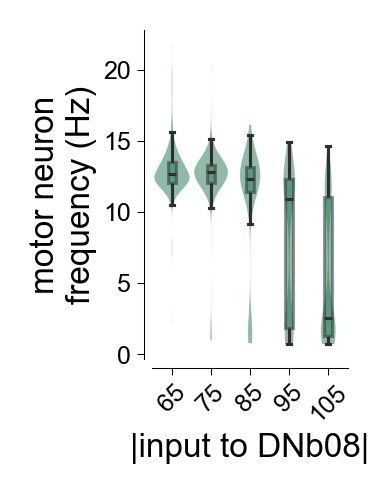

In [4]:
plt.figure(figsize=(0.84,1.426))
sns.violinplot((mnFreq/overallParams.sim.dt).iloc[:,1:].astype(float).melt(var_name="stimI",value_name="frequency"),x="stimI",y="frequency",
               density_norm="area",edgecolor=None,inner=None,cut=0,alpha=0.5,color=mnColor,width=0.9,saturation=1)
sns.boxplot((mnFreq/overallParams.sim.dt).iloc[:,1:].astype(float).melt(var_name="stimI",value_name="frequency"),x="stimI",y="frequency",width=0.2,linewidth=0.75,fliersize=2**0.75,
            boxprops={"alpha":0.5,},showfliers=False,color=mnColor,saturation=1)
plt.gca().tick_params(axis='x', labelrotation=45)
sns.despine(offset=2)

plt.xlabel("|input to DNb08|")
plt.ylabel("motor neuron\nfrequency (Hz)")
plt.gcf().set_dpi(300)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+f"/mnFreqViolinSaturated.svg",transparent=True)
plt.show()

In [5]:
(nMnsActive==0).sum()

55     8
65     0
75     0
85     0
95     0
105    0
dtype: int64

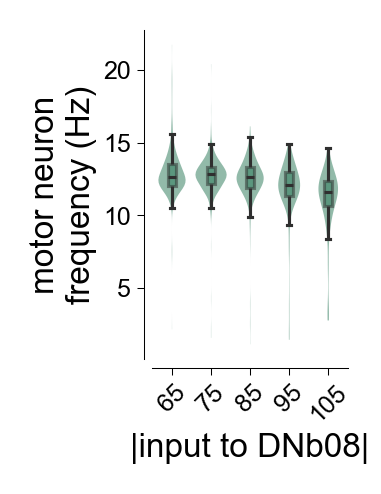

In [6]:
plt.figure(figsize=(0.84,1.426))

sns.violinplot((mnFreq[(nMnsActive<=25)]/overallParams.sim.dt).iloc[:,1:].astype(float).melt(var_name="stimI",value_name="frequency"),
               x="stimI",y="frequency",edgecolor=None,inner=None,cut=0,alpha=0.5,color=mnColor,saturation=1,density_norm="area")
sns.boxplot((mnFreq[(nMnsActive<=25)]/overallParams.sim.dt).iloc[:,1:].astype(float).melt(var_name="stimI",value_name="frequency"),x="stimI",y="frequency",width=0.2,linewidth=0.75,fliersize=2**0.75,
            boxprops={"alpha":0.5,},showfliers=False,color=mnColor,saturation=1)
plt.gca().tick_params(axis='x', labelrotation=45)
sns.despine(offset=2)

plt.xlabel("|input to DNb08|")
plt.ylabel("motor neuron\nfrequency (Hz)")
plt.gcf().set_dpi(300)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+f"/mnFreqViolin_lessThan25mns.svg",transparent=True)
plt.show()

# Connectivity of the DNb08 core circuit

In [2]:
figFolder = "../figures/minicircuit-plots-dnb08"

wTable = feather.read_feather("../data/manc full vnc data/wTable_20251006.feather")
W = feather.read_feather("../data/manc full vnc data/W_20251006.feather").to_numpy().astype(float)

In [3]:
miniTypes = ["DNb08","IN17A001","INXXX466","IN03A006","INXXX464","IN19A007"]
miniTypesToLabels = {"DNb08": "DNb08",
                     "IN17A001": "E1 (IN17A001)",
                     "INXXX466": "E2 (INXXX466)",
                     "IN03A006": "E4 (IN03A006)",
                     "INXXX464": "E5 (INXXX464)",
                     "IN19A007": "I2 (IN19A007)"}

mnData = sort_motor_modules(wTable.loc[(wTable["class"]=="motor neuron") & (wTable["subclass"].isin(["fl","ml","hl"]))])

miniData = wTable.loc[wTable["type"].isin(miniTypes)]
miniData["ticklabel"] = miniData["type"].map(miniTypesToLabels)
miniData = pd.concat([miniData,mnData])
miniData["circuitSide"] = miniData["somaSide"]
miniData["circuitSide"].loc[(miniData["subclass"]=="BR")&(miniData["somaSide"]=="LHS")] = "RHS"
miniData["circuitSide"].loc[(miniData["subclass"]=="BR")&(miniData["somaSide"]=="RHS")] = "LHS"

/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",
/tmp/ipykernel_963522/2163492746.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  miniData["ticklabel"] = miniData["type"].map(miniTypesToLabels)
/tmp/ipykernel_963522/2163492746.py:15: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You 

/tmp/ipykernel_963522/705645529.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  legMiniData["type"] = pd.Categorical(legMiniData["type"],categories=miniTypes+mnData["type"].unique().tolist())
/tmp/ipykernel_963522/705645529.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  legMiniData.sort_values("type",inplace=True)
/tmp/ipykernel_963522/705645529.py:17: FutureWarning: Categorical.to_list is deprecated and will be removed in a future version. Use obj.tolist() instead
  modules = mnData["motor module"].unique().dropna().to_list()


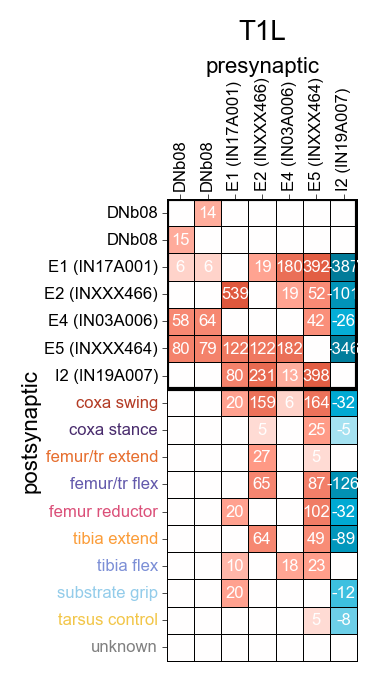

In [4]:
nIns = 7
neuromere = "T1"
side = "LHS"


fig = plt.figure()
legMiniData = miniData.loc[((miniData["circuitSide"]==side) & (miniData["somaNeuromere"]==neuromere)) |
                            (miniData["rootSide"]==side)]

legMiniData["type"] = pd.Categorical(legMiniData["type"],categories=miniTypes+mnData["type"].unique().tolist())
legMiniData.sort_values("type",inplace=True)
miniW = W[np.ix_(legMiniData.index,legMiniData.index)]

moduleGroupedW = miniW[:nIns,:nIns]
annot = True

modules = mnData["motor module"].unique().dropna().to_list()
for mod in modules:
    weightsToMod = np.sum(W[legMiniData.index[:nIns]][:,legMiniData.loc[legMiniData["motor module"]==mod].index],axis=1)
    moduleGroupedW = np.append(moduleGroupedW,np.expand_dims(weightsToMod,axis=1),axis=1)

weightsToUnknown = np.sum(W[legMiniData.index[:nIns]][:,legMiniData.loc[(legMiniData["class"]=="motor neuron") & (legMiniData["motor module"].isna())].index],axis=1)
moduleGroupedW = np.append(moduleGroupedW,np.expand_dims(weightsToUnknown,axis=1),axis=1)
modules += ["unknown"]

ax = sns.heatmap(moduleGroupedW.T,norm = colors.SymLogNorm(10,vmin=-1000,vmax=1000),
            cmap=connColormap,square=True,
            xticklabels=legMiniData["ticklabel"].iloc[:nIns],yticklabels=legMiniData["ticklabel"].iloc[:nIns].tolist()+modules,
            linewidths=0.25, linecolor='black',
            annot=annot,fmt=".0f",clip_on=False,cbar=False,annot_kws={"fontsize":6,"color":connColormap(0.5)})

moduleColors = get_module_colors()
moduleColors["unknown"] = "#808080"
for i in range(len(ax.get_yticklabels())):
    label = ax.get_yticklabels()[i]
    try:
        label.set_color(moduleColors[label.get_text()])
    except:
        label.set_color("#000000")

plt.vlines([0,nIns],0,nIns,colors="k",linewidth=1.5,zorder=10)
plt.hlines([0,nIns],0,nIns,colors="k",linewidth=1.5,zorder=10)
fig = plt.gcf()
ax.tick_params("x",labelrotation=90)
ax.tick_params("y",labelrotation=0)
plt.xlabel("presynaptic")
plt.ylabel("postsynaptic")
plt.title(neuromere + side[0],fontsize=10)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top') 
if annot:
    fig.set_figheight(3)
    fig.set_figwidth(3)
plt.subplots_adjust(right=1.2)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+f"/manc_modules_{neuromere}{side[0]}.svg",transparent=True)
plt.show()

# MANC 1024x DNb08 core CPG 1 only

In [7]:
simType = "DNb08_Stim_CoreCPG_1"
simPath = simType+"/default/run_id=walle_20260223_00"
folder = dataPath + simPath
subfolders = []
for f in os.listdir(folder):
    if os.path.isdir(f"{folder}/{f}"):
        subfolders.append(f)

dataset = 0
parts = []
for subfolder in subfolders:
    print(subfolder)
    parts.append(load_Rs_npz(folder+f"/{subfolder}/ckpt/{simType}_Rs.npz")[dataset])
Rs = sparse.concatenate(parts, axis=0)

params = DictConfig(load_from_yaml(folder+"/multirun.yaml"))
nSims = Rs.shape[0]

wTable = pd.read_csv("../"+params.experiment["dfPath"].split("vnc-connectome-sim")[1])
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])
nMnsActive = pd.Series(index=np.arange(nSims))
nMnsActiveTinyThreshold = pd.Series(index=np.arange(nSims))
simScore = pd.Series(index=np.arange(nSims))

for i in range(nSims):
    # active neurons
    R = Rs[i].todense()
    
    activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    nMnsActive.loc[i] = np.sum(activeMnsMask)
    activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    score, _ = compute_oscillation_score(R[...,250:],activeMnsMaskPastTransient)
    nMnsActiveTinyThreshold.loc[i] = np.sum(activeMnsMaskPastTransient)
    simScore.loc[i] = score

figFolder = "../figures/"
figFolder += "-".join(str.split(simPath,"/"))

experiment.seed=729
experiment.seed=485
experiment.seed=761
experiment.seed=890


/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


## individual traces

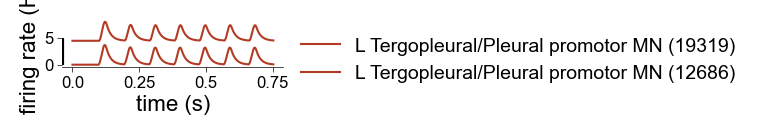

In [8]:
coreCpgData = wTable.loc[params.experiment.keepOnly]
coreCpgData["type"] = pd.Categorical(coreCpgData["type"],["DNb08","IN17A001","INXXX466","IN03A006","INXXX464","IN19A007"],ordered=True)
coreCpgData.sort_values("type",inplace=True)

idx = 458 #np.random.randint(nSims)
spacer = 4.5
scalebar = 5

timeLimit = .75

R = Rs[idx].todense()

plt.figure()
ax = plot_R_traces_stacked_by_module(R[:,:750],mnData,activeOnly=True,space=spacer)# ,colorMapper=colorMapper)
add_tAxis(ax,timeLimit,3.00001)
xlimits = ax.get_xlim()
plt.vlines(xlimits[0],0,scalebar,"k")
plt.yticks([0,scalebar])
plt.xlim(xlimits)
ax.spines[["left","top","right"]].set_visible(False)
fig = plt.gcf()
ax.grid(False)
plt.xlabel("time (s)")


fig.set_figwidth(1.426)
fig.set_figheight(1.226*1/4)


# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+f"/mnTraces_idx{idx}.svg",transparent=True)
plt.show()

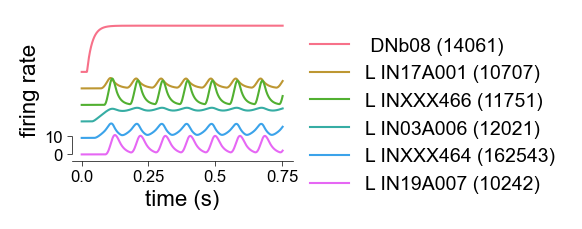

In [9]:
idx = 458

coreCpgData = wTable.loc[params.experiment.keepOnly]
coreCpgData["type"] = pd.Categorical(coreCpgData["type"],["DNb08","IN17A001","INXXX466","IN03A006","INXXX464","IN19A007"],ordered=True)
coreCpgData.sort_values("type",inplace=True)

spacer = 9
width = 3

R = Rs[idx].todense()

plt.figure()
ax = plot_R_traces_stacked_2(R[:,:750],coreCpgData,activeOnly=False,space=spacer,cmap=sns.husl_palette(as_cmap=True))
add_tAxis(ax,0.75,3.0001)
xlimits = ax.get_xlim()
plt.vlines(xlimits[0],0,10,"k",linewidth=0.25)
plt.yticks([0,10])
plt.xlim(xlimits)
ax.spines[["left","top","right"]].set_visible(False)
ax.tick_params(labelsize=6)
ax.grid(False)
# plt.ylabel("firing rate (Hz)",fontsize=8)
plt.xlabel("time (s)")
fig = plt.gcf()
fig.set_figwidth(1.426)
fig.set_figheight(1.226*3/4)

# plt.savefig(figFolder+f"/dnInTraces_idx{idx}.svg",transparent=True)

plt.show()

## overall data

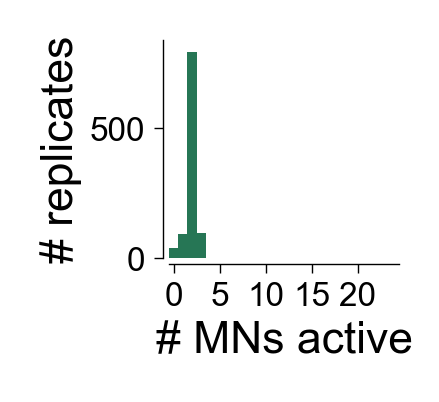

In [10]:
plt.figure(figsize=(0.743,0.710))

ax = sns.histplot(nMnsActive,color=mnColor,edgecolor="none",binwidth=1,kde=False,alpha=1,discrete=True)
plt.ylim([0,840])
plt.xticks(np.arange(0,25,5))
plt.xlim([-0.5,24.5])
plt.ylabel("# replicates",fontsize=8)
plt.xlabel("# MNs active",fontsize=8)
plt.gca().tick_params(axis='both', which='major', labelsize=6)
plt.gcf().set_dpi(400)
sns.despine(offset=1)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/activeMnHist.svg",transparent=True)
plt.show()

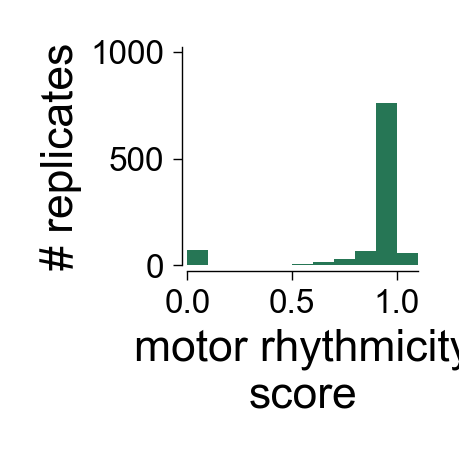

In [11]:
plt.figure(figsize=(0.743,0.710))

ax = sns.histplot(simScore,color=mnColor,edgecolor="none",bins=np.arange(0,1.5,0.1),kde=False,alpha=1.0)
plt.xlim([0,1.1])
plt.ylim([0,1024])
plt.xticks(np.arange(0,1.1,0.5))
plt.xlabel("motor rhythmicity\nscore",fontsize=8)
plt.ylabel("# replicates",fontsize=8)
plt.gca().tick_params(axis='both', which='major', labelsize=6)
plt.gcf().set_dpi(400)
sns.despine(offset=1)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/mnScoreHist.svg",transparent=True)
plt.show()

# MANC 1024x DNb08 core CPG 2 only

In [12]:
simType = "DNb08_Stim_CoreCPG_2"
simPath = simType+"/default/run_id=walle_20260221_02"
folder = dataPath + simPath
subfolders = []
for f in os.listdir(folder):
    if os.path.isdir(f"{folder}/{f}"):
        subfolders.append(f)

dataset = 0
parts = []
for subfolder in subfolders:
    print(subfolder)
    parts.append(load_Rs_npz(folder+f"/{subfolder}/ckpt/{simType}_Rs.npz")[dataset])
Rs = sparse.concatenate(parts, axis=0)

params = DictConfig(load_from_yaml(folder+"/multirun.yaml"))
nSims = Rs.shape[0]

wTable = pd.read_csv("../"+params.experiment["dfPath"].split("vnc-connectome-sim")[1])
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])
nMnsActive = pd.Series(index=np.arange(nSims))
nMnsActiveTinyThreshold = pd.Series(index=np.arange(nSims))
simScore = pd.Series(index=np.arange(nSims))

for i in range(nSims):
    # active neurons
    R = Rs[i].todense()
    
    activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    nMnsActive.loc[i] = np.sum(activeMnsMask)
    activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    score, _ = compute_oscillation_score(R[...,250:],activeMnsMaskPastTransient)
    nMnsActiveTinyThreshold.loc[i] = np.sum(activeMnsMaskPastTransient)
    simScore.loc[i] = score

figFolder = "../figures/"
figFolder += "-".join(str.split(simPath,"/"))

experiment.seed=49
experiment.seed=631
experiment.seed=721
experiment.seed=865


/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


### individual traces

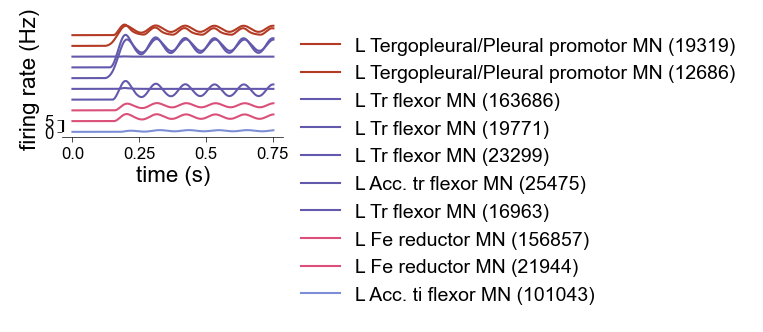

In [13]:
coreCpgData = wTable.loc[params.experiment.keepOnly]

idx = 751 #np.random.randint(nSims)
spacer = 4.5
scalebar = 5

timeLimit = .75

R = Rs[idx].todense()

plt.figure()
ax = plot_R_traces_stacked_by_module(R[:,:750],mnData,activeOnly=True,space=spacer)# ,colorMapper=colorMapper)
add_tAxis(ax,timeLimit,3.00001)
xlimits = ax.get_xlim()
plt.vlines(xlimits[0],0,scalebar,"k")
plt.yticks([0,scalebar])
plt.xlim(xlimits)
ax.spines[["left","top","right"]].set_visible(False)
fig = plt.gcf()
ax.grid(False)
plt.xlabel("time (s)")


fig.set_figwidth(1.426)
fig.set_figheight(1.226*2.5/4)
# fig.set_dpi(500)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+f"/mnTraces_idx{idx}.svg",transparent=True)
plt.show()

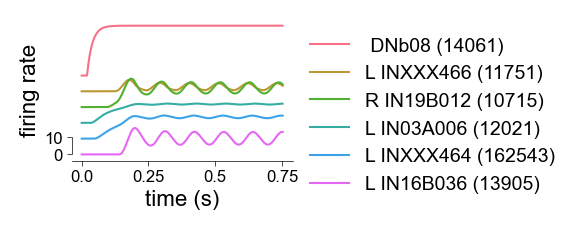

In [14]:
idx = 751

coreCpgData = wTable.loc[params.experiment.keepOnly]
coreCpgData["type"] = pd.Categorical(coreCpgData["type"],["DNb08","INXXX466","IN19B012","IN03A006","INXXX464","IN16B036"],ordered=True)
coreCpgData.sort_values("type",inplace=True)
# coreCpgData.loc[31,"somaSide"] = "LHS"

spacer = 9
width = 3

R = Rs[idx].todense()

plt.figure()
ax = plot_R_traces_stacked_2(R[:,:750],coreCpgData,activeOnly=False,space=spacer,cmap=sns.husl_palette(as_cmap=True))
add_tAxis(ax,0.75,3.0001)
xlimits = ax.get_xlim()
plt.vlines(xlimits[0],0,10,"k",linewidth=0.25)
plt.yticks([0,10])
plt.xlim(xlimits)
ax.spines[["left","top","right"]].set_visible(False)
ax.tick_params(labelsize=6)
ax.grid(False)
# plt.ylabel("firing rate (Hz)",fontsize=8)
plt.xlabel("time (s)")
fig = plt.gcf()
fig.set_figwidth(1.426)
fig.set_figheight(1.226*3/4)

# plt.savefig(figFolder+f"/dnInTraces_idx{idx}.svg",transparent=True)

plt.show()

### overall data

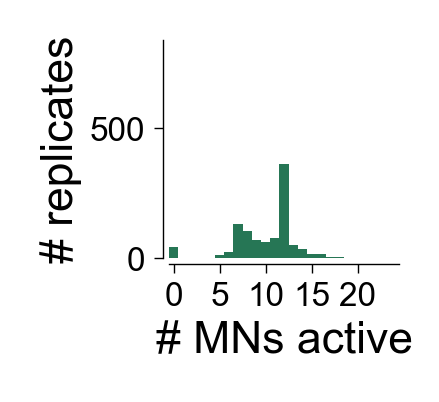

In [15]:
plt.figure(figsize=(0.743,0.710))

ax = sns.histplot(nMnsActive,color=mnColor,edgecolor="none",binwidth=1,kde=False,alpha=1,discrete=True)
plt.ylim([0,840])
plt.xticks(np.arange(0,25,5))
plt.xlim([-0.5,24.5])
plt.ylabel("# replicates",fontsize=8)
plt.xlabel("# MNs active",fontsize=8)
plt.gca().tick_params(axis='both', which='major', labelsize=6)
plt.gcf().set_dpi(400)
sns.despine(offset=1)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/activeMnHist.svg",transparent=True)
plt.show()

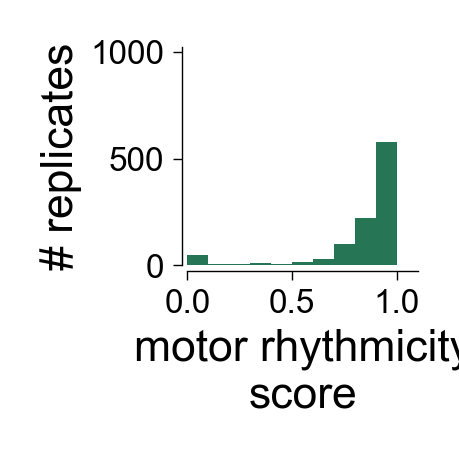

In [16]:
plt.figure(figsize=(0.743,0.710))

ax = sns.histplot(simScore,color=mnColor,edgecolor="none",bins=np.arange(0,1.5,0.1),kde=False,alpha=1.0)
plt.xlim([0,1.1])
plt.ylim([0,1024])
plt.xticks(np.arange(0,1.1,0.5))
plt.xlabel("motor rhythmicity\nscore",fontsize=8)
plt.ylabel("# replicates",fontsize=8)
plt.gca().tick_params(axis='both', which='major', labelsize=6)
plt.gcf().set_dpi(400)
sns.despine(offset=1)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/mnScoreHist.svg",transparent=True)
plt.show()